# Phase Transitions: A Bird's-Eye View

:::{admonition} **What you will learn**
:class: tip

- The concept of phases, phase diagrams, and what distinguishes first-order from continuous (second-order) phase transitions
- The historical development of the Ising model — from Lenz and Ising through Onsager's exact solution to renormalization group theory
- The Ising Hamiltonian: spin variables, nearest-neighbor coupling $J$, and external field $h$
- Critical phenomena: diverging correlation length, universality, and critical exponents
- Thermodynamics of magnetic systems: free energy, magnetization, susceptibility, and heat capacity
- The Peierls argument for why phase transitions occur in 2D but not in 1D at finite temperature
- Applications of the Ising framework beyond magnetism: alloys, spin glasses, biomolecules, neural networks
:::

### Phases, phase diagrams, and phase transitions

- A **phase** is a macroscopic state of matter characterized by uniform physical properties: density, magnetization, crystal structure, etc. A **phase diagram** maps out which phase is stable as a function of thermodynamic variables like temperature and pressure.

- Phase transitions occur when the system crosses a **phase boundary**. But not every path through the diagram encounters one:

:::{figure}
<img src="./figs/phase-diagram.png" alt="phase-diagram" style="width:40%">

Phase diagram for fluids. Path A stays within a single phase — no transition. Path B crosses the coexistence line and undergoes an abrupt phase transition. Path C circumvents the critical point, so the change is gradual and continuous.
:::

### A brief history of phase transitions

**1895 — Pierre Curie** studies magnetism in his doctoral thesis and discovers:
- Magnetic properties change dramatically with temperature
- A sharp phase transition occurs at what is now called the **Curie point**
- The phenomenon has its origin at the atomic scale

![](./figs/Curie.png)

:::{note} **Timeline: from Lenz to the renormalization group**
:class:  dropdown

**1920 — Lenz** proposes a lattice model for ferromagnetism, arguing that atomic dipoles occupy one of two orientations. He assigns the problem to his PhD student.

**1924 — Ernst Ising** solves the one-dimensional version exactly and finds no phase transition. He **incorrectly concludes** that no transition occurs in any dimension, and leaves academic research. Despite this, the paper attracts attention from Pauli, Heisenberg, and Dirac.

**1936 — Rudolf Peierls** proves that the 2D model *does* undergo a finite-temperature phase transition, revitalizing interest and demonstrating the crucial role of dimensionality.

:::{figure}
<img src="./figs/spont-mag.png" alt="spontaneous magnetization" style="width:40%">

Spontaneous magnetization in a ferromagnet: a continuous phase transition from ordered to disordered phase with increasing temperature.
:::

**1941 — Kramers and Wannier** calculate the critical temperature of the 2D model using a duality argument.

**1944 — Lars Onsager** solves the 2D Ising model exactly — a landmark of theoretical physics. Exact expressions for the partition function, free energy, and magnetization follow. Onsager, trained as a chemist, was part of a tradition of chemists (later including Ben Widom) who made foundational contributions to phase transition theory.

**1944 onward** — The Ising model becomes a canonical testing ground for new mathematical techniques: transfer matrices, cluster expansions, combinatorics, and series methods. Applications spread to biology, chemistry, economics, and computer science.

**1970s — Kenneth Wilson** develops the **renormalization group** (Nobel Prize, 1982). Key insights: the critical point is **universal** (translation-, scale-, and rotation-invariant), and coarse-graining explains why microscopically different systems share the same critical behavior.

**1985 — Conformal Field Theory (CFT)** provides an elegant framework for 2D critical systems, linking statistical mechanics and quantum field theory through symmetry principles.
:::

## The Ising Model: the hydrogen atom of phase transitions

:::{figure}
<img src="./figs/arrows-ising.png" alt="ising-lattice" style="width:20%">

The Ising model: each lattice site carries a spin that points either up ($+1$) or down ($-1$).
:::

:::{important} **Ising Hamiltonian**


$$H([s]) = -J\sum_{\langle ij \rangle} s_i s_j \;-\; h \sum_i s_i$$

$$Z = \sum_{[s]} e^{-H([s])/k_B T}$$

- Each spin variable takes two values: $s_i = \pm 1$
- $[s] = [s_1, s_2, \dots]$ denotes a microstate — a complete spin configuration
- $J > 0$: ferromagnetic coupling (parallel spins are favored)
- $h$: external magnetic field
- $\langle ij \rangle$: summation over **nearest-neighbor** pairs only
:::

### What do Ising configurations look like?

Before diving into simulations, let's build visual intuition. The plots below show random spin configurations with increasing alignment bias — from a fully disordered state (high $T$) to a nearly ordered state (low $T$). In reality, the degree of ordering is set self-consistently by the Boltzmann distribution, but even this simple exercise reveals the visual hallmark of a phase transition: a change from a disordered "salt-and-pepper" pattern to large uniform domains.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

biases = [0.5, 0.65, 0.85, 0.98]
labels = ['Disordered\n($T \gg T_c$)', 'Weakly ordered', 'Partially ordered', 'Strongly ordered\n($T \ll T_c$)']
N = 40

for ax, p_up, label in zip(axes, biases, labels):
    spins = np.random.choice([-1, 1], size=(N, N), p=[1 - p_up, p_up])
    ax.imshow(spins, cmap='coolwarm', vmin=-1, vmax=1, interpolation='nearest')
    ax.set_title(label, fontsize=11)
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle('Random spin configurations with increasing alignment bias', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### First-order vs continuous phase transitions

Phase transitions come in two fundamentally different kinds:

- **First-order transitions** involve a discontinuous jump in an order parameter (e.g., density in liquid-gas, magnetization under a field). The system releases or absorbs **latent heat**, and the two phases coexist at the transition. Example: ice melting to water at 0 $^\circ$C.

- **Continuous (second-order) transitions** show no discontinuity in the order parameter itself, but its derivatives (susceptibility, heat capacity) diverge. There is no latent heat and no phase coexistence. Example: the ferromagnetic-to-paramagnetic transition at the Curie temperature.

:::{figure}
<img src="./figs/1st_2nd_Ising (1).png" alt="1st-2nd-order" style="width:50%">

Left: first-order transition with a discontinuous jump in the order parameter. Right: continuous transition where the order parameter vanishes smoothly.
:::

### Critical phenomena: diverging correlation length

Near a continuous phase transition, the **correlation length** $\xi$ — the typical distance over which spins "know about" each other — grows without bound. At $T_c$, the system becomes **scale-invariant**: fluctuations of all sizes coexist, and there is no characteristic length scale left in the problem.

This divergence of $\xi$ is the root cause of all critical phenomena: it is why response functions ($C_V$, $\chi$) diverge, why critical slowing down occurs in dynamics, and why the system looks statistically self-similar at every scale.

:::{figure}
<img src="./figs/crit1.png" alt="correlation-divergence" style="width:50%">

As $T \to T_c$, the correlation length $\xi$ diverges. Spin clusters grow to span the entire system.
:::

### Critical exponents and scaling

Near $T_c$, thermodynamic quantities obey **power laws** characterized by **critical exponents**:

| Quantity | Symbol | Power law | Exponent |
|---|---|---|---|
| Order parameter | $m$ | $m \sim (T_c - T)^\beta$ | $\beta$ |
| Susceptibility | $\chi$ | $\chi \sim |T - T_c|^{-\gamma}$ | $\gamma$ |
| Heat capacity | $C_V$ | $C_V \sim |T - T_c|^{-\alpha}$ | $\alpha$ |
| Correlation length | $\xi$ | $\xi \sim |T - T_c|^{-\nu}$ | $\nu$ |

These exponents are not independent — they are connected by **scaling relations** such as the Rushbrooke inequality $\alpha + 2\beta + \gamma = 2$ and the hyperscaling relation $d\nu = 2 - \alpha$ (where $d$ is the spatial dimension).

![](./figs/crit3.png)

### Universality

The most remarkable feature of critical phenomena is **universality**: systems with completely different microscopic physics share the **same critical exponents** if they have the same:

1. **Spatial dimensionality** $d$
2. **Symmetry of the order parameter** (e.g., scalar vs vector)
3. **Range of interactions** (short- vs long-range)

This is why the liquid-gas critical point, the Curie point in ferromagnets, and the demixing transition in binary fluids all fall into the same **universality class**. The renormalization group explains this: near $T_c$ the correlation length $\xi \to \infty$, and microscopic details are averaged away, leaving only symmetry and dimensionality.

![](./figs/crit4.png)

:::{figure}
<img src="./figs/gas-universality.png" alt="universality-fluids" style="width:40%">

Universality in fluids: different substances collapse onto the same curve when plotted in reduced variables.
:::

:::{figure}
<img src="./figs/universality-ising.png" alt="universality-ising" style="width:40%">

Universality in magnetic systems: different ferromagnets share the same critical exponents.
:::

### Thermodynamics of magnetic systems

For a magnetic system in an external field $B$, the fundamental thermodynamic relation acquires a magnetic work term:

$$dU = T\,dS + B\,dM$$

Performing a Legendre transform to obtain the Helmholtz free energy $F(T, B)$:

$$dF = -S\,dT - M\,dB$$

This gives us direct access to magnetization and entropy as derivatives of $F$:

$$M = -\left(\frac{\partial F}{\partial B}\right)_T, \qquad S = -\left(\frac{\partial F}{\partial T}\right)_B$$

### Fluctuations, correlations, and response functions

The connection between microscopic fluctuations and macroscopic response is a central theme of statistical mechanics. For the Ising model, three quantities play a key role:

**Heat capacity** $C_V$ measures energy fluctuations:

$$C_V(T) = \left(\frac{\partial \langle E \rangle}{\partial T}\right)_V = \frac{1}{k_B T^2}\left(\langle E^2 \rangle - \langle E \rangle^2\right)$$

**Magnetic susceptibility** $\chi$ measures magnetization fluctuations:

$$\chi(T) = \left(\frac{\partial \langle M \rangle}{\partial B}\right)_T = \frac{1}{k_B T}\left(\langle M^2 \rangle - \langle M \rangle^2\right)$$

**Correlation function** $c(i,j)$ quantifies how strongly two spins influence each other:

$$c(i,j) = \langle (s_i - \langle s_i \rangle)(s_j - \langle s_j \rangle) \rangle$$

At high temperature, spins are nearly independent and $c(i,j)$ decays rapidly with distance. At low temperature, spins are strongly correlated over large distances. The **correlation length** $\xi$ characterizes the decay: $c(r) \sim e^{-r/\xi}$. At the critical point, $\xi \to \infty$ and correlations become long-ranged.

### Applications of the Ising model beyond magnetism

The Ising model's power lies in its generality — any system of binary variables with local interactions maps onto it:

1. **Ferromagnetism.** The Ising model is the scalar ($n=1$) special case of the more general Heisenberg model with vector spins.

2. **Binary alloys and lattice gases.** Each site is occupied by atom A ($s_i = +1$) or B ($s_i = -1$). Nearest-neighbor interaction energies $\epsilon_{AA}$, $\epsilon_{BB}$, $\epsilon_{AB}$ map to an effective coupling $J = \epsilon_{AB} - \frac{1}{2}(\epsilon_{AA} + \epsilon_{BB})$. The Ising model thus describes order-disorder transitions in alloy composition.

3. **Spin glasses.** Each bond gets its own coupling $J_{ij}$ drawn from a random distribution, mixing ferromagnetic and antiferromagnetic interactions. This models structurally disordered systems with competing interactions.

4. **Biomolecular conformations.** The helix-coil transition in DNA: $s_i = +1$ means a hydrogen bond is closed, $s_i = -1$ means it is open. The transition between helix and coil is an Ising-like phase transition. Other examples include oxygen-binding cooperativity in hemoglobin and conformational switching in bacterial flagella.

5. **Neural networks.** In the Hopfield model, $s_i = +1$ means a neuron is firing and $s_i = -1$ means it is resting. Boltzmann machines — used in machine learning — are a stochastic generalization of this idea.

6. **Epidemics and opinion dynamics.** In models of disease or rumor spreading, $s_i = +1$ means "infected" and $s_i = -1$ means "susceptible." If nearest-neighbor coupling is strong enough, a macroscopic fraction of the population becomes infected — a phase transition.

## The Peierls Argument

In the 1930s, Rudolf Peierls devised an elegant scaling argument that explains why the Ising model has a phase transition in 2D but not in 1D. The key idea is to compare the **energy cost** of creating a domain of flipped spins against the **entropy gain** from the number of ways to place it.

### No phase transition in 1D at $T > 0$

Start with a 1D chain of $N$ spins, all pointing up. Now create a domain of flipped spins by introducing two domain walls:

$$+ + + + + + {\bf \boxed{-} - - - \boxed{-}} + + + + + +$$

**Energy cost.** Each domain wall breaks one nearest-neighbor bond at a cost of $2J$. Two walls cost:

$$\Delta E = 2 \cdot 2J = 4J$$

**Entropy gain.** The two walls can be placed at any of $\sim N^2/2$ pairs of positions along the chain:

$$\Delta S = k_B \ln \frac{N(N-1)}{2} \approx 2k_B \ln N$$

**Free energy change:**

$$\Delta F = 4J - 2k_B T \ln N$$

For any finite $T$ and $N \gg 1$, $\Delta F < 0$: it is *always* favorable to create domain walls. Entropy wins at every temperature, destroying long-range order. **There is no phase transition in 1D at finite temperature.**

### Phase transition in 2D at $T > 0$

In 2D, a domain of flipped spins is bounded by a closed contour of length $L$ — a macroscopic quantity, unlike the fixed cost of two point-like walls in 1D.

**Energy cost.** Each bond along the contour costs $2J$:

$$\Delta E = 2J \cdot L$$

**Entropy gain.** The number of self-avoiding contours of length $L$ on a square lattice grows roughly as $3^L$ (at each step, the contour can go in $\sim 3$ directions):

$$\Delta S \approx k_B L \ln 3$$

**Free energy change:**

$$\Delta F = L\,(2J - k_B T \ln 3)$$

At low temperatures, $\Delta F > 0$: creating a domain boundary is costly and the ordered phase is stable. Domain walls become favorable only when:

$$T > T_c = \frac{2J}{k_B \ln 3} \approx 1.82\, J/k_B$$

This is a rough estimate (the exact Onsager result is $T_c \approx 2.27\, J/k_B$), but the essential physics is captured: **in 2D, the energy cost of a domain wall grows with its size, and a finite critical temperature exists.**

### Exact solution of the 1D Ising model (transfer matrix)

The 1D Ising model with periodic boundary conditions can be solved exactly using the **transfer matrix method**. For $N$ spins in a ring with coupling $J$ and external field $h$, the partition function is:

$$Z = \text{Tr}(\mathbf{T}^N) = \lambda_+^N + \lambda_-^N$$

where $\mathbf{T}$ is the $2 \times 2$ transfer matrix with eigenvalues:

$$\lambda_{\pm} = e^{\beta J} \cosh(\beta h) \pm \sqrt{e^{2\beta J} \sinh^2(\beta h) + e^{-2\beta J}}$$

In the thermodynamic limit ($N \to \infty$), only the largest eigenvalue matters: $Z \approx \lambda_+^N$. Since $\lambda_+$ is analytic for all finite $T$, the free energy $f = -k_BT \ln \lambda_+$ has no singularity — confirming that **no phase transition occurs in 1D**.

<>:51: SyntaxWarning: invalid escape sequence '\;'
<>:54: SyntaxWarning: invalid escape sequence '\;'
<>:57: SyntaxWarning: invalid escape sequence '\;'
<>:60: SyntaxWarning: invalid escape sequence '\;'
<>:51: SyntaxWarning: invalid escape sequence '\;'
<>:54: SyntaxWarning: invalid escape sequence '\;'
<>:57: SyntaxWarning: invalid escape sequence '\;'
<>:60: SyntaxWarning: invalid escape sequence '\;'
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/1365231200.py:51: SyntaxWarning: invalid escape sequence '\;'
  axes[0, 0].set(ylabel='$\\langle E \\rangle / N$', xlabel='$T \; [J/k_B]$')
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/1365231200.py:54: SyntaxWarning: invalid escape sequence '\;'
  axes[0, 1].set(ylabel='$\\langle |M| \\rangle / N$', xlabel='$T \; [J/k_B]$')
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/1365231200.py:57: SyntaxWarning: invalid escape sequence '\;'
  axes[1, 0].set(ylabel='$C_V / N k_B$', xlabel='$T \

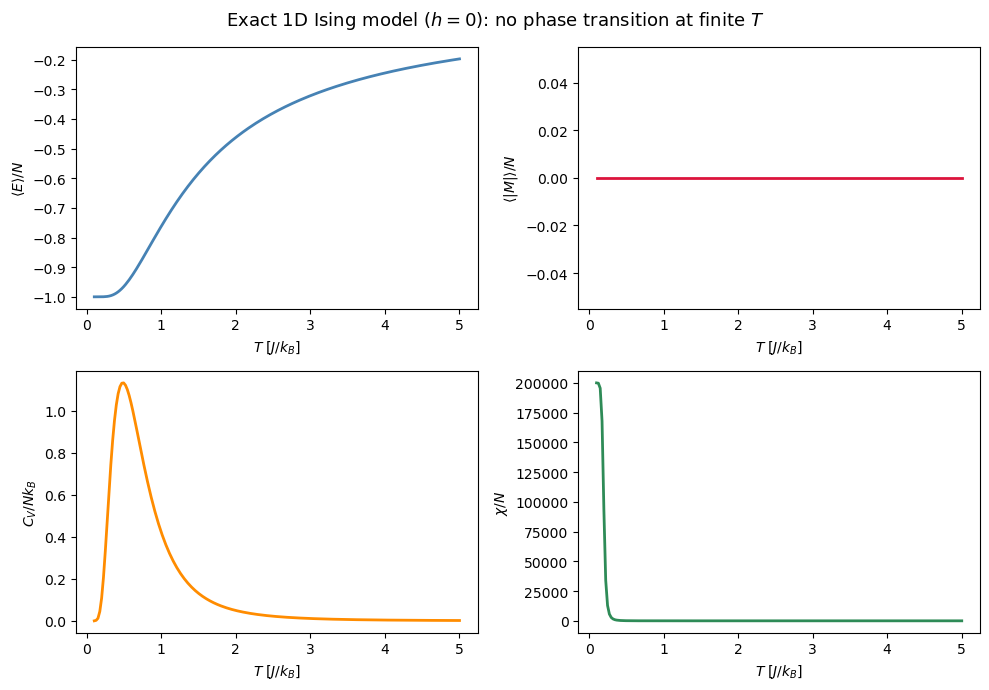

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def ising_1d_exact(T_range, J=1.0, h=0.0):
    """Exact thermodynamics of the 1D Ising model via transfer matrix."""
    E_list, M_list, Cv_list, chi_list = [], [], [], []

    for T in T_range:
        beta = 1.0 / T

        # Transfer matrix eigenvalues
        lam_p = np.exp(beta * J) * np.cosh(beta * h) + np.sqrt(
            np.exp(2 * beta * J) * np.sinh(beta * h)**2 + np.exp(-2 * beta * J))

        # Free energy per spin
        def log_lam_plus(b):
            return np.log(np.exp(b * J) * np.cosh(b * h) + np.sqrt(
                np.exp(2 * b * J) * np.sinh(b * h)**2 + np.exp(-2 * b * J)))

        def free_energy(TT):
            return -TT * log_lam_plus(1.0 / TT)

        def free_energy_h(hh):
            bb = beta
            return -T * np.log(np.exp(bb * J) * np.cosh(bb * hh) + np.sqrt(
                np.exp(2 * bb * J) * np.sinh(bb * hh)**2 + np.exp(-2 * bb * J)))

        # Numerical derivatives
        dT = T * 1e-5
        dbeta = beta * 1e-5
        dh = 1e-5

        E = -(log_lam_plus(beta + dbeta) - log_lam_plus(beta - dbeta)) / (2 * dbeta)
        Cv = -(free_energy(T + dT) - 2 * free_energy(T) + free_energy(T - dT)) / (dT**2) / T
        M = -(free_energy_h(h + dh) - free_energy_h(h - dh)) / (2 * dh)
        chi = -(free_energy_h(h + dh) - 2 * free_energy_h(h) + free_energy_h(h - dh)) / (dh**2)

        E_list.append(E)
        M_list.append(abs(M))
        Cv_list.append(Cv)
        chi_list.append(chi)

    return np.array(E_list), np.array(M_list), np.array(Cv_list), np.array(chi_list)

T = np.linspace(0.1, 5.0, 200)
E, M, Cv, chi = ising_1d_exact(T, J=1.0, h=0.0)

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(T, E, color='steelblue', lw=2)
axes[0, 0].set(ylabel='$\\langle E \\rangle / N$', xlabel='$T \; [J/k_B]$')

axes[0, 1].plot(T, M, color='crimson', lw=2)
axes[0, 1].set(ylabel='$\\langle |M| \\rangle / N$', xlabel='$T \; [J/k_B]$')

axes[1, 0].plot(T, Cv, color='darkorange', lw=2)
axes[1, 0].set(ylabel='$C_V / N k_B$', xlabel='$T \; [J/k_B]$')

axes[1, 1].plot(T, chi, color='seagreen', lw=2)
axes[1, 1].set(ylabel='$\\chi / N$', xlabel='$T \; [J/k_B]$')

fig.suptitle('Exact 1D Ising model ($h = 0$): no phase transition at finite $T$', fontsize=13)
plt.tight_layout()
plt.show()

The 1D results confirm the Peierls argument: energy and magnetization change smoothly — there is no singularity, no divergence in $C_V$ or $\chi$, and no spontaneous magnetization at any $T > 0$. The heat capacity shows a broad **Schottky-like peak** rather than a sharp divergence.

### Exact enumeration of a small 2D Ising lattice

For small enough lattices, we can enumerate **every microstate** and compute the partition function exactly. A $4 \times 4$ lattice has $2^{16} = 65{,}536$ states — perfectly tractable.

This brute-force approach gives us exact thermodynamic averages and reveals the signatures of the 2D phase transition: a peak in $C_V$ and $\chi$ near $T_c$, and a smooth crossover in $\langle E \rangle$ and $\langle |M| \rangle$. Compare the sharp features here with the smooth 1D curves above.

<>:61: SyntaxWarning: invalid escape sequence '\;'
<>:66: SyntaxWarning: invalid escape sequence '\;'
<>:70: SyntaxWarning: invalid escape sequence '\;'
<>:74: SyntaxWarning: invalid escape sequence '\;'
<>:61: SyntaxWarning: invalid escape sequence '\;'
<>:66: SyntaxWarning: invalid escape sequence '\;'
<>:70: SyntaxWarning: invalid escape sequence '\;'
<>:74: SyntaxWarning: invalid escape sequence '\;'
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/3285649429.py:61: SyntaxWarning: invalid escape sequence '\;'
  axes[0, 0].set(ylabel='$\\langle E \\rangle / N$', xlabel='$T \; [J/k_B]$')
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/3285649429.py:66: SyntaxWarning: invalid escape sequence '\;'
  axes[0, 1].set(ylabel='$\\langle |M| \\rangle / N$', xlabel='$T \; [J/k_B]$')
/var/folders/77/92dtv6bs0gn66v7t347kmd_w0000gp/T/ipykernel_35738/3285649429.py:70: SyntaxWarning: invalid escape sequence '\;'
  axes[1, 0].set(ylabel='$C_V / N k_B$', xlabel='$T \

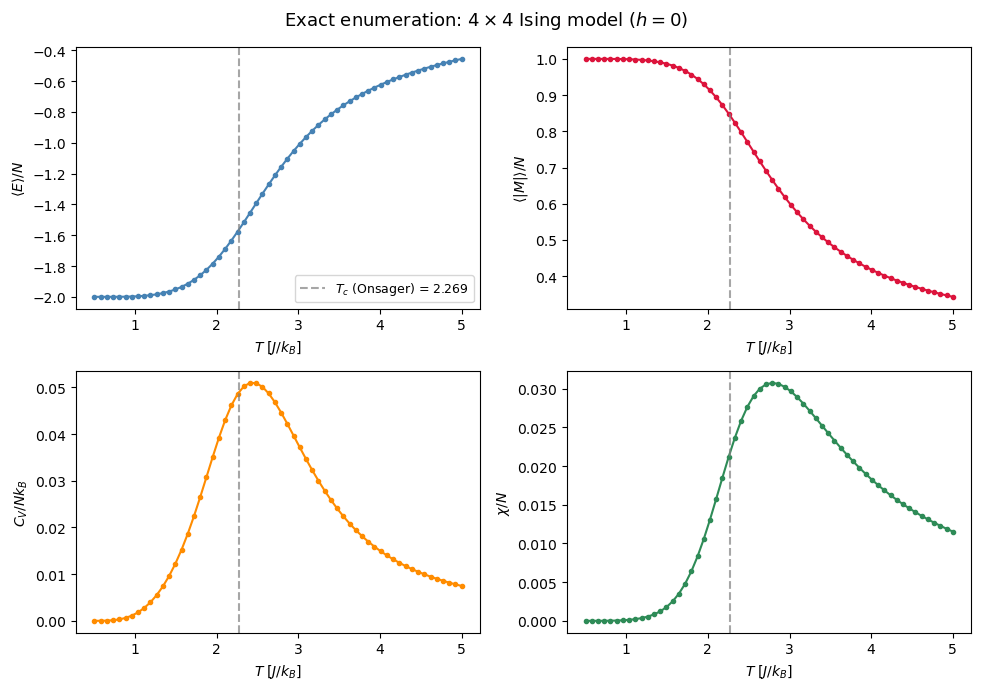

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product

def exact_ising_2d(L, J=1.0, h=0.0, T_range=np.linspace(0.5, 5.0, 60)):
    """Exact enumeration of all 2^(L*L) states for an L x L Ising model with PBC."""
    N = L * L
    sites = list(product([-1, 1], repeat=N))

    # Precompute neighbor pairs (right and down, with periodic boundaries)
    neighbors = []
    for i in range(L):
        for j in range(L):
            idx = i * L + j
            right = i * L + (j + 1) % L
            down = ((i + 1) % L) * L + j
            neighbors.append((idx, right))
            neighbors.append((idx, down))

    # Energy and magnetization for every microstate
    energies = np.zeros(len(sites))
    mags = np.zeros(len(sites))
    for k, state in enumerate(sites):
        s = np.array(state)
        E = 0.0
        for (a, b) in neighbors:
            E -= J * s[a] * s[b]
        E -= h * np.sum(s)
        energies[k] = E
        mags[k] = np.sum(s)

    # Thermodynamic averages at each temperature
    results = {'T': T_range, 'E': [], 'M': [], 'Cv': [], 'chi': []}
    for T in T_range:
        beta = 1.0 / T
        logw = -beta * energies
        logw -= logw.max()
        w = np.exp(logw)
        Z = w.sum()
        p = w / Z

        E_avg = np.dot(p, energies) / N
        E2_avg = np.dot(p, energies**2) / N**2
        M_avg = np.dot(p, np.abs(mags)) / N
        M2_avg = np.dot(p, mags**2) / N**2

        results['E'].append(E_avg)
        results['M'].append(M_avg)
        results['Cv'].append((E2_avg - (np.dot(p, energies) / N)**2) / T**2)
        results['chi'].append((M2_avg - M_avg**2) / T)

    return results

res = exact_ising_2d(L=4)
Tc_onsager = 2.0 / np.log(1 + np.sqrt(2))

fig, axes = plt.subplots(2, 2, figsize=(10, 7))

axes[0, 0].plot(res['T'], res['E'], 'o-', color='steelblue', ms=3)
axes[0, 0].axvline(Tc_onsager, ls='--', color='gray', alpha=0.7, label=f'$T_c$ (Onsager) = {Tc_onsager:.3f}')
axes[0, 0].set(ylabel='$\\langle E \\rangle / N$', xlabel='$T \; [J/k_B]$')
axes[0, 0].legend(fontsize=9)

axes[0, 1].plot(res['T'], res['M'], 'o-', color='crimson', ms=3)
axes[0, 1].axvline(Tc_onsager, ls='--', color='gray', alpha=0.7)
axes[0, 1].set(ylabel='$\\langle |M| \\rangle / N$', xlabel='$T \; [J/k_B]$')

axes[1, 0].plot(res['T'], res['Cv'], 'o-', color='darkorange', ms=3)
axes[1, 0].axvline(Tc_onsager, ls='--', color='gray', alpha=0.7)
axes[1, 0].set(ylabel='$C_V / N k_B$', xlabel='$T \; [J/k_B]$')

axes[1, 1].plot(res['T'], res['chi'], 'o-', color='seagreen', ms=3)
axes[1, 1].axvline(Tc_onsager, ls='--', color='gray', alpha=0.7)
axes[1, 1].set(ylabel='$\\chi / N$', xlabel='$T \; [J/k_B]$')

fig.suptitle('Exact enumeration: $4 \\times 4$ Ising model ($h = 0$)', fontsize=13)
plt.tight_layout()
plt.show()

- Even on this tiny $4 \times 4$ lattice, the hallmarks of the 2D phase transition are visible: energy drops steeply near $T_c$, magnetization builds up below $T_c$, and both $C_V$ and $\chi$ develop peaks near the Onsager critical temperature $T_c \approx 2.269\, J/k_B$. On larger lattices — accessible only via Monte Carlo — these peaks sharpen and diverge in the thermodynamic limit.